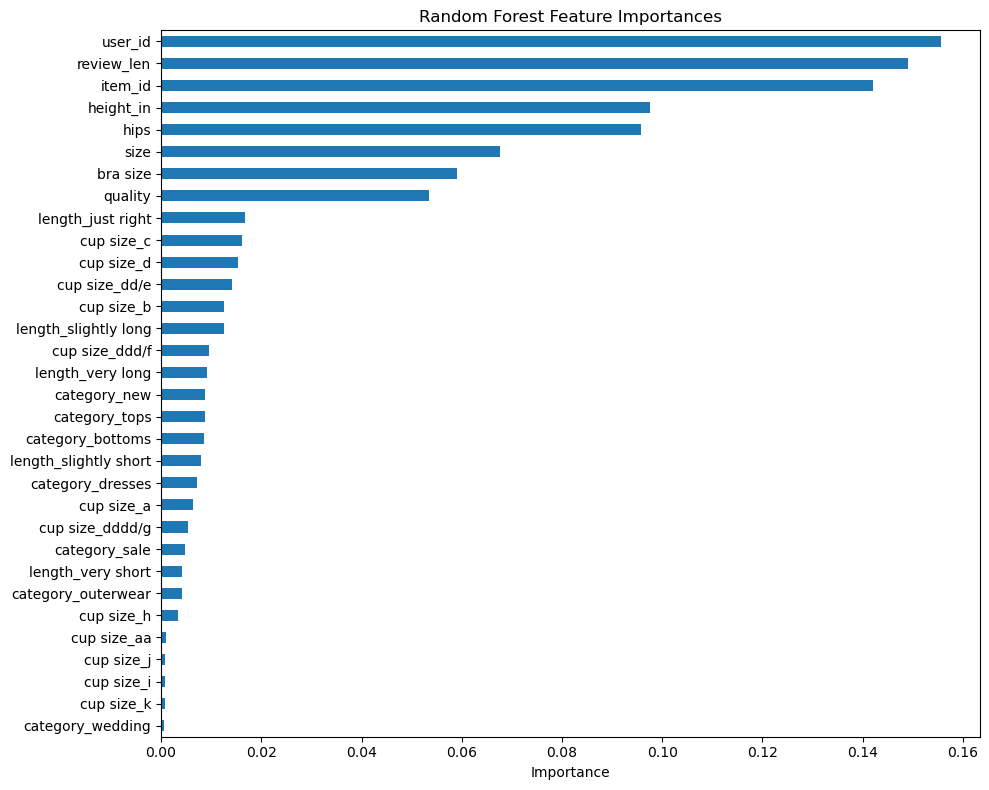

Top 5 features:
user_id       0.155636
review_len    0.149026
item_id       0.142011
height_in     0.097636
hips          0.095828
dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Load X_train, y_train
data = pd.read_pickle("../data/processed/modcloth_final_train.pkl")
X_train = data["X_train"]
y_train = data["y_train"]

# Train a basic RandomForest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot all features (will show all columns, even if not exactly 32)
plt.figure(figsize=(10, 8))
importances.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Top 5 features
top5 = importances.head(5)
print("Top 5 features:")
print(top5)


Step 4: Initial Feature Importance & Noise Identification
The ID Problem: Initial training identified user_id and item_id as the most significant predictors. Mathematically, these are high-cardinality categorical identifiers that lead to overfitting rather than predictive insight.

Target Leakage Risk: The model is currently memorizing individual user behaviors rather than learning the relationship between body measurements and fit.

Refinement Strategy: To ensure the B2Spoke engine can predict fit for new users, these identification columns must be removed. This will force the model to rely on generalized features like review_len, hips, and height_in.

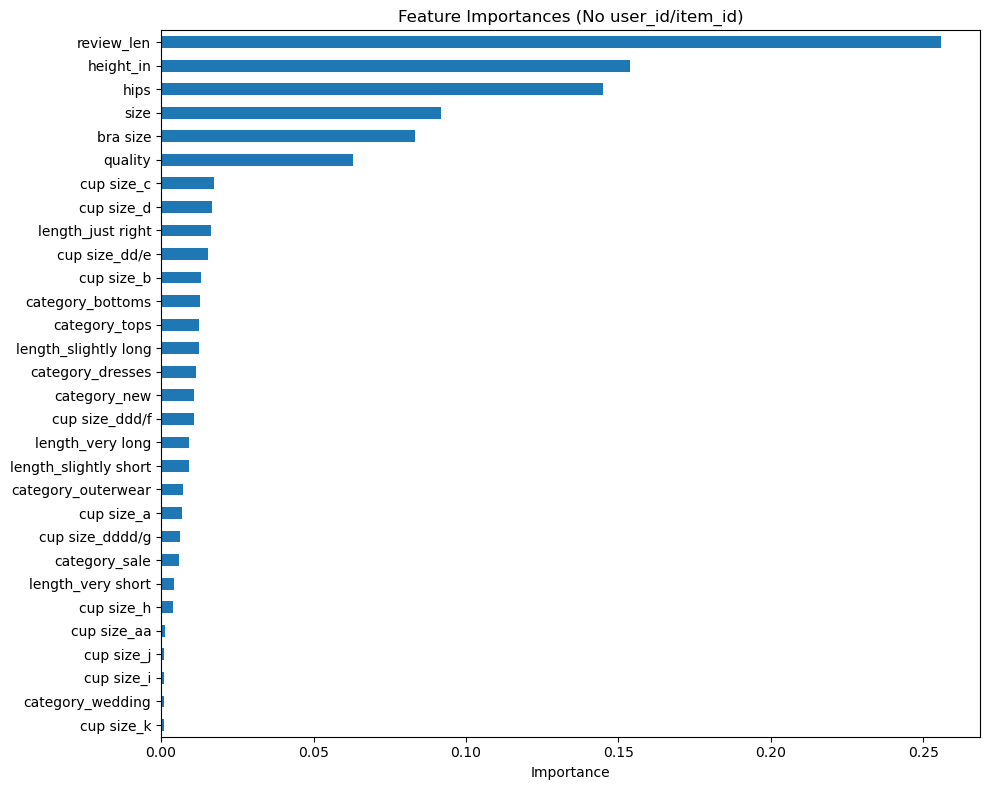

Top 10 features:
review_len           0.255852
height_in            0.153780
hips                 0.144817
size                 0.091869
bra size             0.083330
quality              0.063064
cup size_c           0.017341
cup size_d           0.016778
length_just right    0.016535
cup size_dd/e        0.015486
dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Drop user_id and item_id
X_train_final = X_train.drop(columns=["user_id", "item_id"], errors="ignore")

# Re-train Random Forest
rf2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf2.fit(X_train_final, y_train)

# Feature importances
importances2 = pd.Series(rf2.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 8))
importances2.sort_values().plot(kind="barh")
plt.title("Feature Importances (No user_id/item_id)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Verify top features
print("Top 10 features:")
print(importances2.head(10))


Step 4 Conclusion: Feature Importance & Generalization
Noise Mitigation: Removing user_id and item_id transitioned the model from memorizing specific instances to learning generalized physical and qualitative relationships.

Primary Predictors: review_len (0.25) and height_in (0.15) are the dominant signals, suggesting that fit is best predicted through a combination of body metrics and customer sentiment.

The Role of Quality: Ranking at 6.3% importance, quality serves as a critical secondary signal. This indicates that while body shape is the primary driver of fit, the perceived quality of the garment significantly influences whether a customer labels an item as 'fit' or a failure.

Measurement Synergy: The high rankings of hips, size, and bra size validate the Step 3 imputation strategy; the model is heavily utilizing these recovered data points for classification.